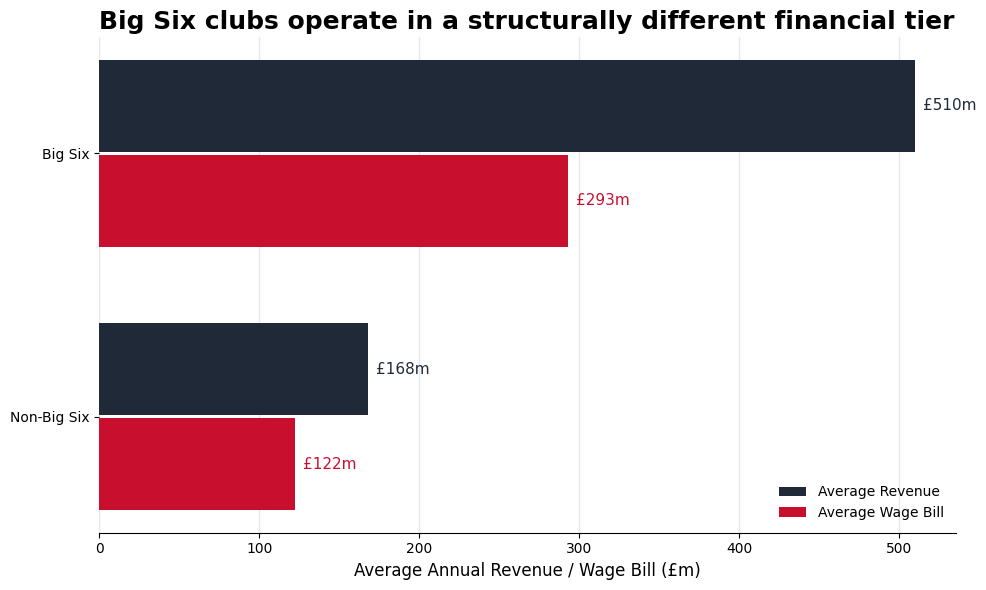

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# Styling
# -------------------------

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 12

PRIMARY = "#C8102E"      # Sunderland red
SECONDARY = "#1F2937"    # Dark charcoal
GRID = "#E5E7EB"

# -------------------------
# Load data
# -------------------------

DATA_PATH = Path("../data/master/modelling_features.csv")

BIG_SIX = {
    "Arsenal",
    "Chelsea",
    "Liverpool",
    "Manchester City",
    "Manchester United",
    "Tottenham",
}

df = pd.read_csv(DATA_PATH)

df["club_group"] = df["team_name"].apply(
    lambda x: "Big Six" if x in BIG_SIX else "Non-Big Six"
)

summary = (
    df.groupby(["year", "club_group"])
    .agg(
        avg_revenue=("revenue", "mean"),
        avg_wage_bill=("wage_bill", "mean"),
    )
    .reset_index()
)

plot_df = (
    summary.groupby("club_group")
    .agg(
        avg_revenue=("avg_revenue", "mean"),
        avg_wage_bill=("avg_wage_bill", "mean"),
    )
    .reset_index()
)

# -------------------------
# Plot
# -------------------------

fig, ax = plt.subplots(figsize=(10, 6))

groups = plot_df["club_group"]

y_positions = [1, 0]

revenue = plot_df["avg_revenue"]
wages = plot_df["avg_wage_bill"]

bar_height = 0.35

ax.barh(
    [y + 0.18 for y in y_positions],
    revenue,
    height=bar_height,
    color=SECONDARY,
    label="Average Revenue",
)

ax.barh(
    [y - 0.18 for y in y_positions],
    wages,
    height=bar_height,
    color=PRIMARY,
    label="Average Wage Bill",
)

# Value labels

for i, val in enumerate(revenue):
    ax.text(
        val + 5,
        y_positions[i] + 0.18,
        f"£{val:.0f}m",
        va="center",
        fontsize=11,
        color=SECONDARY,
    )

for i, val in enumerate(wages):
    ax.text(
        val + 5,
        y_positions[i] - 0.18,
        f"£{val:.0f}m",
        va="center",
        fontsize=11,
        color=PRIMARY,
    )

# -------------------------
# Formatting
# -------------------------

ax.set_yticks(y_positions)
ax.set_yticklabels(groups)

ax.set_xlabel("Average Annual Revenue / Wage Bill (£m)")
ax.set_title(
    "Big Six clubs operate in a structurally different financial tier",
    loc="left",
)

ax.grid(
    axis="x",
    color=GRID,
    linewidth=1,
)

ax.set_axisbelow(True)

# Remove unnecessary borders

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right",
)

plt.tight_layout()

plt.savefig(
    "../data/outputs/big_six_vs_non_big_six_financials.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()